<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Mecanica-celeste/Tarea2_Sistemas_Jerarquicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<img src="https://drive.google.com/uc?id=1ZHUKcwzA5c-PKUwoGmBG3TsHk6TmZ-Y0" align="left" width="250">
</p><p><br>

<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 2</center></b><h2>
<h3><b><center>Sistemas Jerárquicos de N-cuerpos</center></b><h3>
<h5><center><b>Asignada</b>: 29 de Agosto de 2023</center><h5>
<h5><center><b>Entrega</b>: 12 de Septiembre de 2023</center><h5>
</p>

<br><br><br>

<hr/>
<b>Nombre</b>: Juan Manuel Cardenas
<br/>
<b>Cédula</b>: 1002587562
<br/>
<b>Última actualización</b>: 12-9-23
<hr/>
<br>


In [ ]:
# Instalacion de librerias
!pip install -q pymcel  # libreria general del profe
!pip install -q celluloid # animaciones

In [ ]:
# librerias
import pymcel as pc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.constants as cte
import plotly.graph_objects as go
from celluloid import Camera # animacion
from IPython.display import HTML # ver animacion
from tqdm import tqdm # control de tiempos

In [ ]:
# Parametros y constantes importantes
au    = cte.au.value   # [m]
G     = cte.G.value    # [m^3/s^2*kg]
d_2_s = 24*60*60       # dias a [s]
rad = 180/np.pi        # [°] a [rads]

# unidades canonicas (G = 1 [u_l^3/u_t^2*u_m] )
u_l = 0.01*au                # longitud [m]
u_m = 80*cte.M_jup.value     # masa [kg]
u_t = (u_l**3/(G*u_m))**0.5  # tiempo [s]

In [ ]:
# unidad canonica en dias
u_t/d_2_s

0.21036048415793238

### **Objetivo**:
* El objetivo de esta tarea es poner a prueba la idea de que es posible simular un  sistema de N-cuerpos jerarquicos usando un *árbol* de sistemas de 2 cuerpos.

* En particular compararemos la predicción de las posiciones que para un sistema múltiple de estrellas nos da la simulación con un sistema jerárquico y el mismo resultado pero calculado como si el sistema fuera un sistema de N cuerpos completo.

### **Enunciado y Procedimiento**:

El sistema que simularemos es el de un sistema binario formado por dos estrellas "s" y "e".  Alrededor de la estrella "e" gira un planeta "p", a cuyo alrededor, a su vez, gira una luna "L". Las unidades canonicas se tomaron de la siguiente forma para que el valor numerico de $G=1$:<br>

> $\left\{\begin{matrix}
U_l = & 0.01 \quad [au]      \\
U_m = & 80 \quad [M_{\rm Jup}] \\
U_t = & 0.2103 \quad [dias]
\end{matrix}\right.$

Los datos de los cuerpos en unidades canónicas:
- Masas: s = 1, e = 0.5, L = 0.001, p = 0.01.

Condiciones iniciales (las posiciones están dadas respecto al cuerpo más masivo de cada subsistema):

- Sistema p-L planeta-luna:
     - Posición inicial de p : r = [0,0,0]
     - Velocidad inicial de p: v = [0,0,0]
     - Posición inicial de L: r = [0.03,0,0]
     - Velocidad inicial de L: v = [0,0.4,0.1]
   
- Sistema e-pL (baricentro de p y L):
     - Posición inicial de e : r = [0,0,0]
     - Velocidad inicial de e: v = [0,0,0]
     - Posición inicial de pL: r = [0,0.4,0]
     - Velocidad inicial de pL: v = [0.9,0,0.2]

- Sistema s-epL (baricentro e y pL):
    - Posición inicial de s : r = [0,0,0]
    - Velocidad inicial de s: v = [0,0,0]
    - Posición inicial de epL: r = [2,3,0]
    - Velocidad inicial de epL: v = [-0.2,0.7,0] <br><br>


### **Arbol Jerarquico**

1. Dibujar el árbol del sistema jerárquico como lo hicimos en clase.

<p align="center">
<img src=https://i.postimg.cc/7ZpnN7Cv/arbol-jerarquico.jpg width="600">
</p>

<br>

Para empezar con el codigo primero se definen las **condiciones iniciales** agrupadas en un dataframe donde los valores de las columnas son arreglos $2$-dimensionales contienen informacion de cada **par** del subsistema (el primer elemento corresponde al cuerpo mayor y el segundo al baricentro del resto del subsistema). las columanas son: nombres, vectores posicion, y vectores velocidad.

Del mismo modo se definieron las masas jeraquicas de cada subsistema, agrupadas en arreglos donde el primer valor corresponde al cuerpo mayor y el segundo a la suma del resto del subsistema, de la siguiente forma: <br>
* **S-EPL** $\quad$ [$1$, $0.511$] <br>
* **E-PL** $\quad$ [$0.5$, $0.011$] <br>
* **P-L** $\quad$ [$0.01$, $0.001$] <br>



In [ ]:
m = [1,0.5,0.01,0.001] # masas objetos de mayor a menor

# condiciones iniciales de cada subsistema (r0, v0)
data = pd.DataFrame({'subsistemas':['s-epl','e-pl','p-l'],
                    'r':[ [[0,0,0], [2,3,0]],
                          [[0,0,0], [0,0.4,0]],
                          [[0,0,0], [0.03,0,0]] ],
                    'v':[ [[0,0,0], [-0.2,0.7,0]],
                          [[0,0,0], [0.9,0,0.2]],
                          [[0,0,0], [0,0.4,0.1]] ]  })

nombres_subs = data['subsistemas'] # nombres subsistemas

# masas jerarquicas
m_jer = []
for i in range(len(data)):
  m_jer.append( [m[i], sum(m[i+1:])] )

# tiempo de integracion
ts = np.linspace(0,55,150)

### **Solucion Jerarquica** del sistema SEPL

2. Simular usando `ncuerpos_solucion` cada subsistema por separado y obtener el vector y la velocidad relativa como función del tiempo de cada subsistema.


A continuacion se crea un ciclo para integrar los 3 susbsistemas pares con la funcion `ncuerpos_solucion` de Pymcel, es decir se resuelve como problema de $2$ cuerpos, con lo que se encuentra la solucion del objeto mayor del subsistema y del baricentro de los cuerpos del restantes del subsistema (debido a que las condiciones iniciales y las masas estan planteadas de esta forma). Estas soluciones se guardan en una lista desde el subsistema mas "grande" al mas "pequeño". y con una funcion se calculan los vectores relativos de posicion y velocidad que serán necesarios para  transformar de coordenadas de Jacobi (relativos y baricentro) a coordenadas fisicas.

In [ ]:
solucion = [] # solucion de sistemas
relativos =[] # vectores relativos

def vec_relativo(solucion): # solucion = [r,v,rp,vp,cuadrs]
  r_rela = solucion[0][0,:,:]-solucion[0][1,:,:] # r relativo
  v_rela = solucion[1][0,:,:]-solucion[1][1,:,:] # v relativo
  return np.array([r_rela, v_rela]) # [0:r, 1:v]

# solucion sistemas jerarquicos
for i in tqdm(range(len(data))):
  sistem=[dict(m= m_jer[i][0], r=data['r'][i][0], v=data['v'][i][0]),   # mayor
          dict(m= m_jer[i][1], r=data['r'][i][1], v=data['v'][i][1])  ] # menor

  solucion.append( pc.ncuerpos_solucion(sistem, ts) )
  relativos.append( vec_relativo( solucion[i] ) ) # [r,v] relativos

100%|██████████| 3/3 [00:15<00:00,  5.05s/it]


#### Grafico de los **vectores relativos** de cada subsistema: <br>

Este solo es un paso intermedio como recordatorio de que las soluciones iniciales encontradas no corresponden con las coordenadas fisicas. y tambien para verificar con que tiempo total de integracion se cumplia un periodo (aproximadamente con 55 unidades canonicas de tiempo)

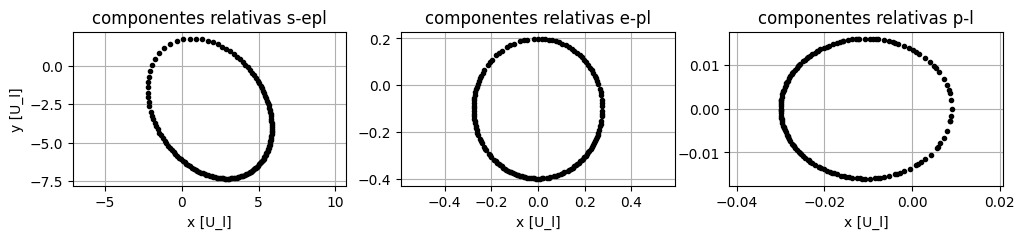

In [ ]:
# grafica vectores relativos
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,2))
ax[0].set_ylabel('y [U_l]')

for i in range(len(relativos)):
  ax[i].set_title(f'componentes relativas {nombres_subs[i]}')
  ax[i].plot(relativos[i][0][:,0], relativos[i][0][:,1],'k.')
  ax[i].set_xlabel('x [U_l]')
  ax[i].axis("equal")
  ax[i].grid()

### **Volviendo al Espacio Fisico**:

3. Suponiendo que el centro de masa de todo el sistema está en reposo en el origen, calcular a partir la solución al problema relativo de cada subsistema, la posición de cada cuerpo en el tiempo.

Con centro de masa total del sistema en el origen y en reposo, es decir $\vec{R_{cm}}=\vec{0}$ y $\vec{V_{cm}}=\vec{0}$, y teniendo en cuenta las Transformaciones de coordenadas Jacobi a las coordenadas Fisicas:

> #### Transf. a **coordenadas Jacobi:**
> \begin{cases}
 & \vec{r} = \vec{r}_{1} - \vec{r}_{2} &  \\
 & M \vec{R}=m_{1}\vec{r_{1}}+m_{2}\vec{r_{2}} &
\end{cases}

> #### Transf. a **coordenadas fisicas:**
> \begin{cases}
 & \vec{r}_{2} = \vec{R} - \vec{r} m_{1}/M  &  \\
 & \vec{r}_{1} = \vec{R} + \vec{r} m_{2}/M &
\end{cases}

(Para la velocidad se toma la derivada de las posiciones y las ecuaciones quedan similares).

Asi pues, con los vectores posicion y velocidad encontrados en la solucion anterior (coords Jacobi) se crea un ciclo que con el uso de las transformaciones mencionadas arroja las coordenadas fisicas (posicion y velocidad) de cada uno de los cuerpos del sistema. para esta parte se debe empezar desde el subsistema mas general hasta el mas pequeño, como se muestra en el Arbol Jerarquico. Finalmente las soluciones de cada cuerpo se guardan en los arreglos posicion $r$ y velocidad $v$


In [ ]:
# Volviendo a coords fisicas
cm = np.zeros( (2,len(ts),3) ) # definicion [Rcm,Vcm] total (origen y reposo)
r = [] ; v = []  # r,v fisicos
R = [] ; V = []  # Rcm, Vcm fisicos

for i in range(len(m_jer)):
  R.append(cm[0]) ; V.append(cm[1])

  # Transf al sistema fisico
  rv_i = cm  +  m_jer[i][1]/sum(m[i:])  *  relativos[i] # [r,v]
  RV_i = cm  -  m_jer[i][0]/sum(m[i:])  *  relativos[i] # [Rcm,Vcm]
  cm  = RV_i # centro de masa [Rcm,Vcm] siguiente

  r.append(rv_i[0]) ; v.append(rv_i[1])

  if i == len(m_jer)-1 : # ultimo caso, el Rcm es el r del mas pequeño
    r.append(cm[0]) ;v.append(cm[1])

En la siguiente grafica se muestran las posiciones reales de los cuerpos y se muestran por pares. (mas adelante se grafican juntos, esta solo era para visualizar el movimiento por separado e intentar deducir el periodo con el tiempo total de integracion)

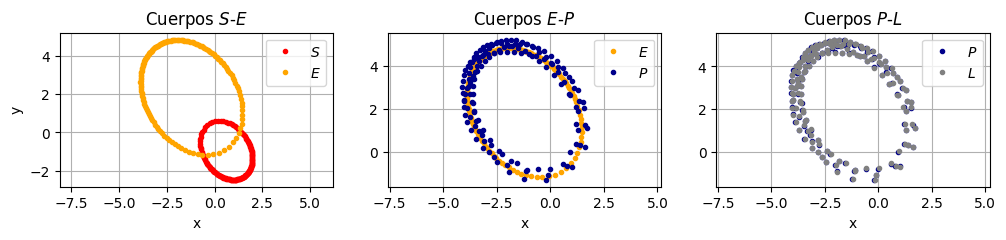

In [ ]:
# grafica de los cuerpos para visualizar orbitas
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,2))
c = ['red','orange','darkblue','gray']
name = ['$S$','$E$','$P$','$L$']
ax[0].set_ylabel('y')

for i in range(len(m_jer)):
  ax[i].set_title(f'Cuerpos {name[i]}-{name[i+1]}')
  ax[i].plot(r[i][:,0], r[i][:,1], f'{c[i]}',
             marker='.', linestyle='None', label=f'{name[i]}')
  ax[i].plot(r[i+1][:,0], r[i+1][:,1], f'{c[i+1]}',
             marker='.', linestyle='None', label=f'{name[i+1]}')
  ax[i].set_xlabel('x')
  ax[i].axis("equal")
  ax[i].grid()
  ax[i].legend()

Para el tiempo total de simulación encuentre el período orbital de cada subsistema ¿cuánto es?. El tiempo de la simulación será igual al período más largo.
Con una aproximacion visual se observa que el objeto con el periodo orbital mas grande es la de la estrella E, con aproximadamente 55 unidades canonicas de tiempo.
<br><br>



### **Solucion por N-cuerpos** para el sistema SEPL

5. Tomando las posiciones iniciales calculadas en 3, use otra vez `ncuerpos_solucion` para encontrar las posiciones y velocidades de todas las partículas respecto del centro de masa. Haga un gráfico de la solución obtenida y cálcule con el obtenido en 4. ¿Se ven parecidas?

para este paso basta con tomar como condiciones iniciales los primeros valores de los arreglos de posicion y velocidad encontrados en el paso anterior, y junto con las masas individuales encontrar la solucion, que en este caso seria para n=4 cuerpos con la funcion `ncuerpos_solucion`

In [ ]:
sistema_total = [dict(m= m[0], r= r[0][0,:], v= v[0][0,:]),  # s
                 dict(m= m[1], r= r[1][0,:], v= v[1][0,:]),  # e
                 dict(m= m[2], r= r[2][0,:], v= v[2][0,:]),  # p
                 dict(m= m[3], r= r[3][0,:], v= v[3][0,:])]  # l
rs, vs, rps, vps, cuads = pc.ncuerpos_solucion( sistema_total, ts )

#### **Gráfico conjuntos de las posiciones**
4. Haga gráficos de las posiciones y una animación que muestre la trayectoria de las partículas.

El punto 5 se realizo antes del 4 con el fin de obtener y comparar las graficas de las posiciones reales de cada cuerpo a traves de ambas soluciones Jerarquica ($r$) y n-cuerpos ($rs$). A continuacion se muestran ambas soluciones.

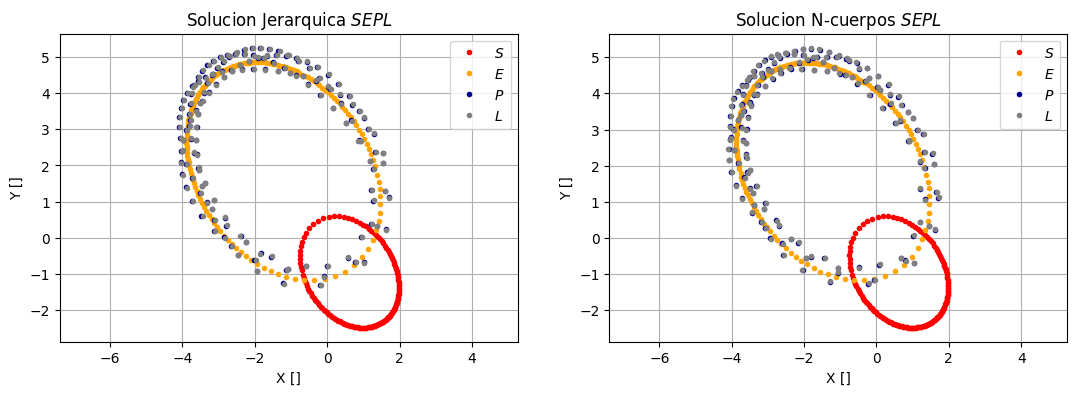

In [ ]:
# grafica del sistema por n-cuerpos
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13,4))

for i in range( len(r) ):
  ax[0].plot(r[i][:,0], r[i][:,1], marker ='.',
           linestyle='None', c=f'{c[i]}', label=f'{name[i]}')

  ax[1].plot(rs[i][:,0], rs[i][:,1], marker ='.',
           linestyle='None', c=f'{c[i]}', label=f'{name[i]}')

ax[0].set_title("Solucion Jerarquica $SEPL$")
ax[0].set_ylabel('Y []')
ax[0].set_xlabel('X []')
ax[0].axis("equal")
ax[0].legend()
ax[0].grid()

ax[1].set_title("Solucion N-cuerpos $SEPL$")
ax[1].set_ylabel('Y []')
ax[1].set_xlabel('X []')
ax[1].axis("equal")
ax[1].legend()
ax[1].grid()

En principio ambas soluciones luncen practicamente identicas, pero vamos a verificar que tanto difieren sus componentes graficamente en el proximos puntos. <br><br>

#### **Animacion** de la solucion **jerarquica**

Como ambas soluciones lucen tan identicas, la animacion puede hacerse con cualquiera de las dos soliciones, basta con cambiar $r$ (jerarquica) por $rs$ (n-cuerpos). En este caso solo se realizó con la solucion jerarquica.
Ademas, dependiendo de la cantidad de puntos de tiempo de integracion elegidos la animacion puede tardar mayor tiempo.

In [ ]:
# grafica del sistema para animacion
fig = plt.figure(figsize=(6,3))
cam = Camera(fig)
plt.title("Sistema Jerarquico $SEPL$")
plt.ylabel('Y []')
plt.xlabel('X []')
plt.axis("equal")
plt.grid()

for i in range(len(ts)):
  plt.plot(r[0][i,0], r[0][i,1], 'r.')
  plt.plot(r[1][i,0], r[1][i,1], 'orange', marker='.', linestyle='None')
  plt.plot(r[2][i,0], r[2][i,1], 'darkblue', marker='.', linestyle='None')
  plt.plot(r[3][i,0], r[3][i,1], 'gray', marker='.', linestyle='None')
  cam.snap() # captura frame

plt.close() # cierra figura, solo interesa la siguiente celda de animacion

In [ ]:
# animacion
anim = cam.animate() # velocidad: interval=20
HTML(anim.to_html5_video())

**visualizacion 3d**

In [ ]:
trazas = [] # Crea trazas con posiciones de cada objeto
for i in range(len(r)):
    trace = go.Scatter3d(x= r[i][:,0],
                         y= r[i][:,1],
                         z= r[i][:,2],
                         name = name[i],
                         mode='markers',
                         marker=dict(color=f'{c[i]}', size=2) )
    trazas.append(trace) # agrega las trazas

# Grafica
fig = go.Figure(trazas) # Crea figura
fig.update_layout(title='Aproximacion Jerarquica Sistema Binario SEPL',
                  scene=dict(xaxis_title='X []',
                             yaxis_title='Y []',
                             zaxis_title='Z []',
                             zaxis=dict(range=[-4,4]),
                             aspectmode='cube' ) )
fig.show()

#### **Gráficos de las Componentes Jerarquicas-n_cuerpos**

6. Haga gráficos de las componentes x, y, z de la posición de cada partícula del sistema a lo largo del tiempo, calculadas con la aproximación jerárquica (punto 3) y con la solución al sistema completo (punto 5). Un gráfico por cuerpo. Comente su resultado.

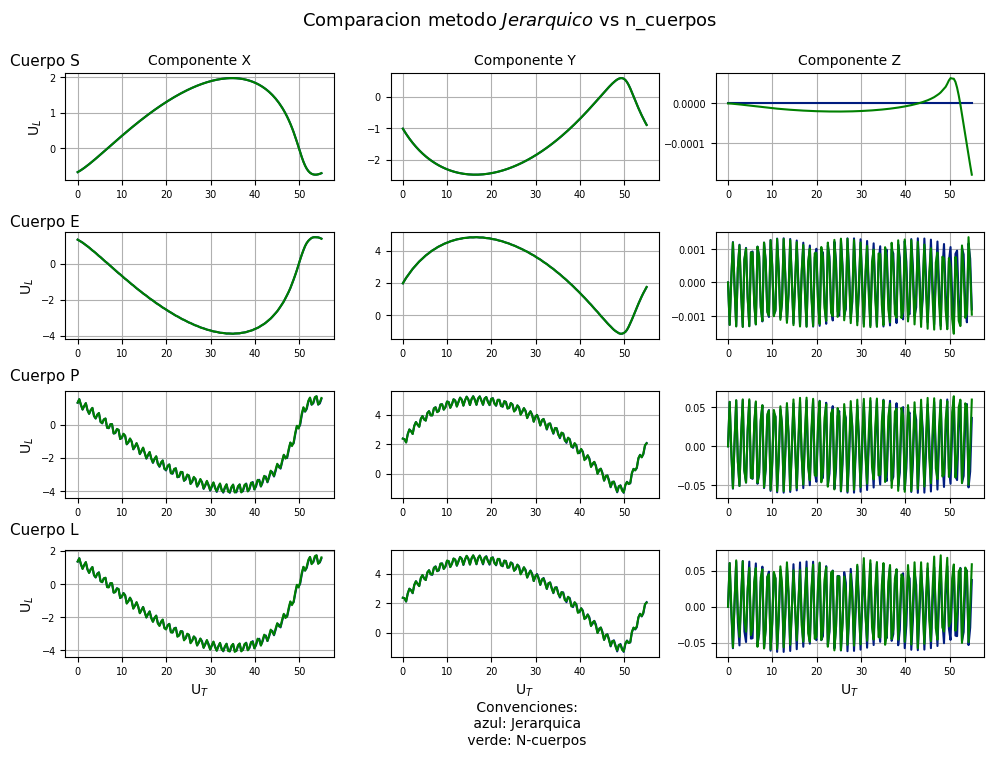

In [ ]:
plt.style.use('seaborn-v0_8-dark-palette')
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(10,7))

fig.suptitle('Comparacion metodo $Jerarquico$ vs n_cuerpos\n', fontsize=13)
fig.tight_layout( h_pad=1.7, w_pad=0.4 ) # espacio vertical-horizontal
comp = ['X','Y','Z']

for i in range(len(r)): # cuerpos (4)
  ax[i,0].set_ylabel('U$_L$')
  for j in range(3):   # componentes (3)
    ax[i,j].plot(ts, r[i][:,j])
    ax[i,j].plot(ts, rs[i][:,j],'g')
    ax[i,j].grid()
    ax[i,j].tick_params(axis='both', labelsize=7)
    ax[0,j].set_title(f'Componente {comp[j]}', fontsize=10)
    ax[3,j].set_xlabel('U$_T$')
ax[3,1].set_xlabel('U$_T$\n Convenciones:\n azul: Jerarquica\n verde: N-cuerpos')

fig.text(0, 0.9, 'Cuerpo S', ha='left', fontsize=11) # titulos de cada cuerpo
fig.text(0, 0.67, 'Cuerpo E', ha='left', fontsize=11)
fig.text(0, 0.45, 'Cuerpo P', ha='left', fontsize=11)
fig.text(0, 0.23, 'Cuerpo L', ha='left', fontsize=11)
fig.show()

Al igual que en las graficas de las posiciones de cada cuerpo, ambas soluciones lucen tan identicas que se superponen ambas curvas. En este caso no es tan relevante la forma de la curva que toma el valor de las componentes de la posicion en funcion del tiepo (aunque si puede dar indicios de sobre que plano se encuentran las orbitasl), sino que tanto difieren un metodo del otro, y como se observa, no lo hacen en gran medida.




#### **Graficando Energias**

7. Haga gráficos de la energía cinética total, la energía potencial total y la energía mecánica total como función del tiempo usando los resultados en 3. El gráfico debe expresarse en unidades más convencionales: en el eje x el tiempo en días,  en el eje y la energía en Joules. ¿Qué observa?

Para las energias de la solucion jerarquica se usó el parte del codigo de la tarea 1, mientras que para las energias de la solucion n-cuerpos se extrajeron de las cuadraturas de la funcion solucion_ncuerpos

In [ ]:
U = [] # potencial
K = np.zeros((len(m),len(ts))) # cinetica

for i in range(len(m)): # cada cuerpo

  # Cinetica  K = 0.5m*v^2 [kg m^2/s^2]
  for k in range(len(ts)): # cada tiempo
    K[i][k] = 0.5 * m[i] * np.dot( v[i][k,:], v[i][k,:] )

  # Potencial U = -G*mi*mj/r_ij [kg m^2/s^2]
  for j in range(len(m)): # cada cuerpo
    if i!=j and i<j :
      U_ij = - m[i]*m[j]/ np.linalg.norm(r[i]-r[j], axis=1)
      U.append(U_ij)

la energia total se calula entonces con la suma de cada una de las energias en cada tiempo, comentada esta la multiplicacion por el factor de transformacion de unidades canonicas al sistema internacional Joules

In [ ]:
# Energia mecanica total
K_t = sum(K) #* (u_m * u_l**2/(u_t**2)) # [Um Ul^2/Ut^2]
U_t = sum(U) #* (u_m * u_l**2/(u_t**2)) # [Um Ul^2/Ut^2]
E_t = K_t + U_t

# Energia mecanica totalo original
U_nbody = cuads['U'] #* (u_m * u_l**2/(u_t**2)) # [Um Ul^2/Ut^2]
K_nbody = cuads['K'] #* (u_m * u_l**2/(u_t**2)) # [Um Ul^2/Ut^2]
E_nbody = K_nbody + U_nbody

In [ ]:
t = ts *u_t/d_2_s # cambio del tiempo a dias

#### **Grafica de las energias** y comparacion de ambos metodos

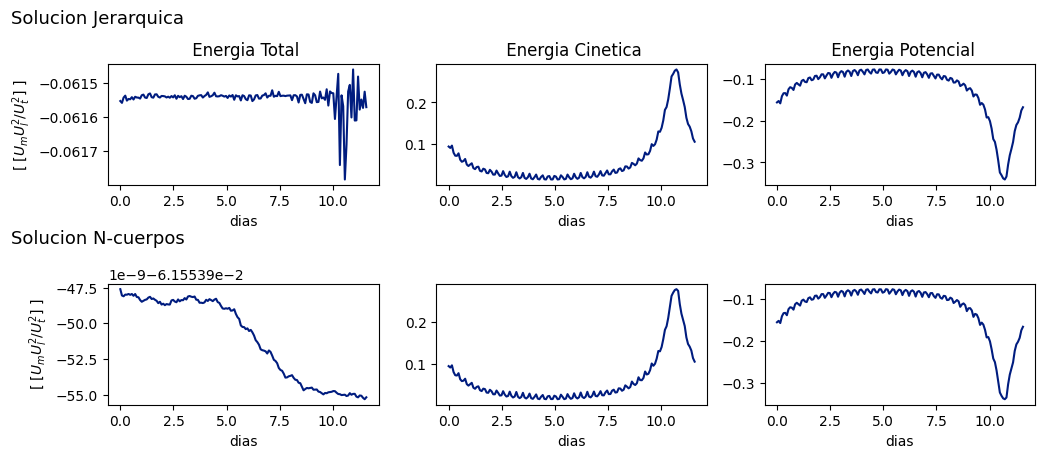

In [ ]:
plt.style.use('seaborn-v0_8-dark-palette')

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(10,4))
fig.tight_layout( h_pad=5 ) # espacio vertical-horizontal
fig.text(-0.05, 1.05, 'Solucion Jerarquica', ha='left', fontsize=13)
fig.text(-0.05, 0.5, 'Solucion N-cuerpos', ha='left', fontsize=13)

# primer fila
ax[0,0].plot(t, E_t)
ax[0,1].plot(t, K_t)
ax[0,2].plot(t, U_t)
ax[0,0].set_title('\n Energia Total')
ax[0,1].set_title('\n Energia Cinetica')
ax[0,2].set_title('\n Energia Potencial')
ax[0,0].set_ylabel('[ $[U_m U_l^2/U_t^2]$ ]')
ax[0,0].set_xlabel('dias')
ax[0,1].set_xlabel('dias')
ax[0,2].set_xlabel('dias')

# segunda fila
ax[1,0].plot(t, E_nbody)
ax[1,1].plot(t, K_nbody)
ax[1,2].plot(t, U_nbody)
ax[1,0].set_ylabel('[ $[U_m U_l^2/U_t^2]$ ]')
ax[1,0].set_xlabel('dias')
ax[1,1].set_xlabel('dias')
ax[1,2].set_xlabel('dias')
plt.show()

Se obtuvo que con el metodo jerarquico el valor medio en unidades canonicas de la energia es aproximadamente -0.0615, que concuerda con el valor medio de la solucion n-cuerpos. Resaltando que las fluctuaciones o variaciones de energia para n-cuerpos son del orden de 1e-9, mientras que para la solucion jerarquica son de aproximadamente 0.0002. A exepcion de los picos al final del periodo de tiempo, que se supone se dan cuando las estrellas se encuentran mas cerca entre si. Teniendo todo esto en cuenta junto con los resultados de las graficas anteriores, se podria afirmar que la solucion mediante el problema de 2 cuerpos por metodo jerarquico es una relativamente buena, como primera aproximacion al problema de n-cuerpos.

<br><br>
______

**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Gráficos mínimos:
  - Gráficos solicitados en cada punto.

- Datos mínimos:
  - Números solicitados en cada punto.

- Gráficos opcionales:
  - Animación mostrando el movimiento de una de las partículas, predicho con la aproximación jerarquica y con la integración precisa.

  - Gráfico de la energía cinética, potencial y total para la simulación de N-cuerpos (punto 5).

- En caso de utilizar ayudas como `ChatGPT` o códigos de `Stack Over Flow` debe citar debidamente la fuente, pero también entender a cabalidad el código, el profesor puede pedir justificación.

In [ ]:
# un patron que puede surgir de aca es que los arreglos se pueden usar mas facilmente para guradar cosas de un tamaño conocido, y las listas para algo que se desconoce.